In [1]:
import os
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import rasterio
from rasterstats import zonal_stats

### 1. Відкрийте векторні дані за допомогою GeoDataFrame та побудуйте їх на графіку

In [2]:
gadm_files = [os.path.join(root, file)
              for root, dirs, files in os.walk("dataa/_data/gadm/")
              for file in files if file.startswith("gadm")]
print(gadm_files)

['dataa/_data/gadm/gadm41_GBR_0.cpg', 'dataa/_data/gadm/gadm41_GBR_0.dbf', 'dataa/_data/gadm/gadm41_GBR_0.prj', 'dataa/_data/gadm/gadm41_GBR_0.shp', 'dataa/_data/gadm/gadm41_GBR_0.shx', 'dataa/_data/gadm/gadm41_GBR_1.cpg', 'dataa/_data/gadm/gadm41_GBR_1.dbf', 'dataa/_data/gadm/gadm41_GBR_1.prj', 'dataa/_data/gadm/gadm41_GBR_1.shp', 'dataa/_data/gadm/gadm41_GBR_1.shx', 'dataa/_data/gadm/gadm41_GBR_2.cpg', 'dataa/_data/gadm/gadm41_GBR_2.dbf', 'dataa/_data/gadm/gadm41_GBR_2.prj', 'dataa/_data/gadm/gadm41_GBR_2.shp', 'dataa/_data/gadm/gadm41_GBR_2.shx', 'dataa/_data/gadm/gadm41_GBR_3.cpg', 'dataa/_data/gadm/gadm41_GBR_3.dbf', 'dataa/_data/gadm/gadm41_GBR_3.prj', 'dataa/_data/gadm/gadm41_GBR_3.shp', 'dataa/_data/gadm/gadm41_GBR_3.shx', 'dataa/_data/gadm/gadm41_GBR_4.cpg', 'dataa/_data/gadm/gadm41_GBR_4.dbf', 'dataa/_data/gadm/gadm41_GBR_4.prj', 'dataa/_data/gadm/gadm41_GBR_4.shp', 'dataa/_data/gadm/gadm41_GBR_4.shx']


Text(98.79392150582684, 0.5, 'Latitude')

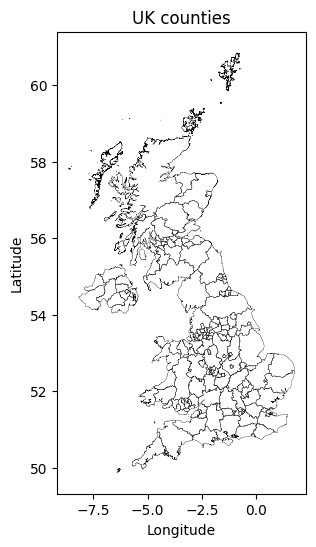

In [6]:
gadm_files_level2 = [file for file in gadm_files if "2.shp" in file]
shps = [gpd.read_file(shp) for shp in gadm_files_level2]
uk_counties = gpd.GeoDataFrame(pd.concat(shps, ignore_index=True))
fig, ax = plt.subplots(figsize=(5, 6))
uk_counties.plot(ax=ax, edgecolor='k', facecolor='none', linewidth=0.2)
ax.set_title('UK counties')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

### 2. Відкрийте растрові дані за допомогою rioxarray та побудуйте їх. Перевірте, чи все працює та не дає збоїв.

In [7]:
nights_light_1992_path ='dataa/night_lights/F101992.v4b_web.stable_lights.avg_vis.tif'
nights_light_2013_path ='dataa/night_lights/F182013.v4c_web.stable_lights.avg_vis.tif'
nights_light_1992 = rioxarray.open_rasterio(nights_light_1992_path)
nights_light_2013 = rioxarray.open_rasterio(nights_light_2013_path)

In [15]:
nights_light_1992

<xarray.DataArray (band: 1, y: 16801, x: 43201)> Size: 726MB
[725820001 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 134kB 75.0 74.99 74.98 ... -64.98 -64.99 -65.0
  * x            (x) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:  100
    TIFFTAG_YRESOLUTION:  100
    AREA_OR_POINT:        Area
    scale_factor:         1.0
    add_offset:           0.0

In [16]:
nights_light_2013

<xarray.DataArray (band: 1, y: 16801, x: 43201)> Size: 726MB
[725820001 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 134kB 75.0 74.99 74.98 ... -64.98 -64.99 -65.0
  * x            (x) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:  1
    TIFFTAG_YRESOLUTION:  1
    AREA_OR_POINT:        Area
    scale_factor:         1.0
    add_offset:           0.0

MemoryError: Unable to allocate 692. MiB for an array with shape (1, 16801, 43201) and data type uint8

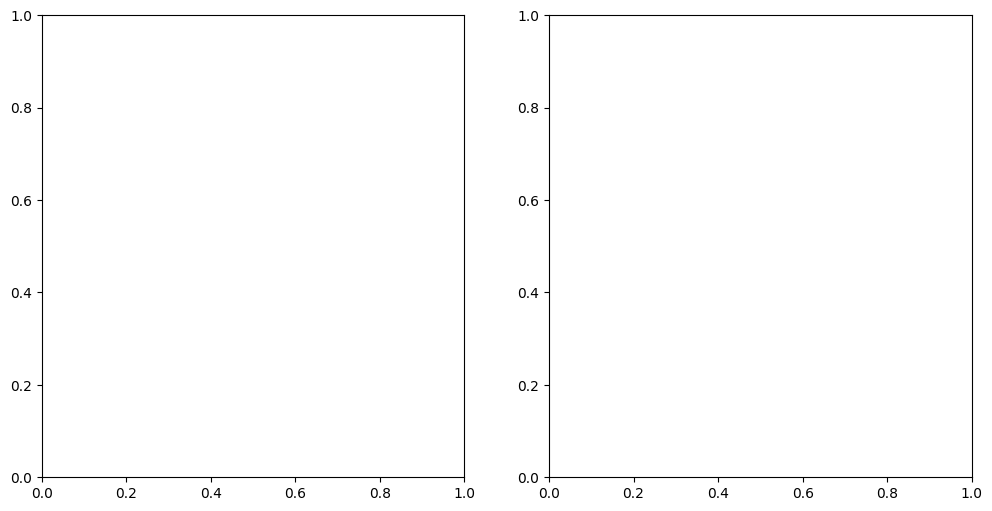

In [17]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
nights_light_1992.plot(ax=ax1, cmap="cividis")
ax1.set_title("Night Lights 1992")
ax1.axis("off")

nights_light_2013.plot(ax=ax2, cmap="cividis")
ax2.set_title("Night Lights 2013")
ax2.axis("off")

plt.tight_layout()
plt.show()

### 3. Спробуйте зменшити розмір растрових даних у 10 разів. Як би ви це зробили?

In [8]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 7.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52499,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52519,Total threads: 1
Dashboard: http://127.0.0.1:52524/status,Memory: 1.93 GiB
Nanny: tcp://127.0.0.1:52502,


In [9]:
nights_light_1992_dask = rioxarray.open_rasterio(nights_light_1992_path, chunks={"x":5000,"y":5000})
nights_light_2013_dask   = rioxarray.open_rasterio(nights_light_2013_path, chunks={"x":5000,"y":5000})

nights_light_1992_dask.rio.write_crs("EPSG:4326", inplace=True)
nights_light_2013_dask.rio.write_crs("EPSG:4326", inplace=True)


<xarray.DataArray (band: 1, y: 16801, x: 43201)> Size: 726MB
dask.array<open_rasterio-a5e7e3eadb1ce10a53134dc630bce7dc<this-array>, shape=(1, 16801, 43201), dtype=uint8, chunksize=(1, 5000, 5000), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 134kB 75.0 74.99 74.98 ... -64.98 -64.99 -65.0
  * x            (x) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_XRESOLUTION:  1
    TIFFTAG_YRESOLUTION:  1
    AREA_OR_POINT:        Area
    scale_factor:         1.0
    add_offset:           0.0

In [10]:
nights_light_1992_small = nights_light_1992_dask.coarsen(x=10, y=10, boundary="trim").mean()
nights_light_2013_small = nights_light_2013_dask.coarsen(x=10, y=10, boundary="trim").mean()

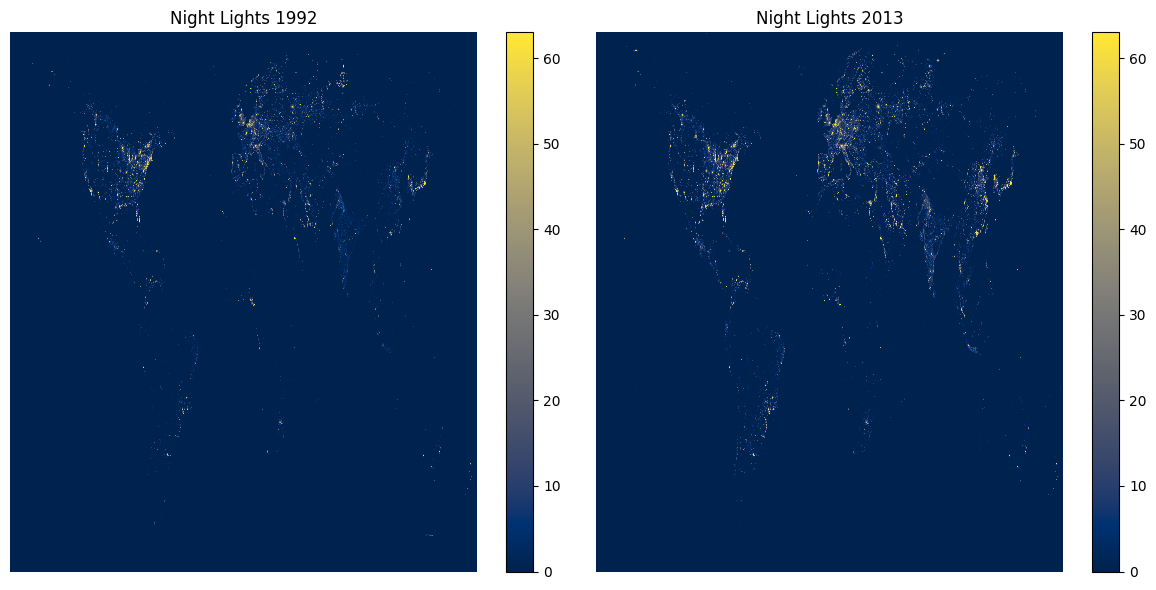

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
nights_light_1992_small.plot(ax=ax1, cmap="cividis")
ax1.set_title("Night Lights 1992")
ax1.axis("off")

nights_light_2013_small.plot(ax=ax2, cmap="cividis")
ax2.set_title("Night Lights 2013")
ax2.axis("off")

plt.tight_layout()
plt.show()


### 4. Обріжте/замаскуйте растрові дані так, щоб вони відповідали векторній геометрії векторних даних вашої країни. Побудуйте графік.

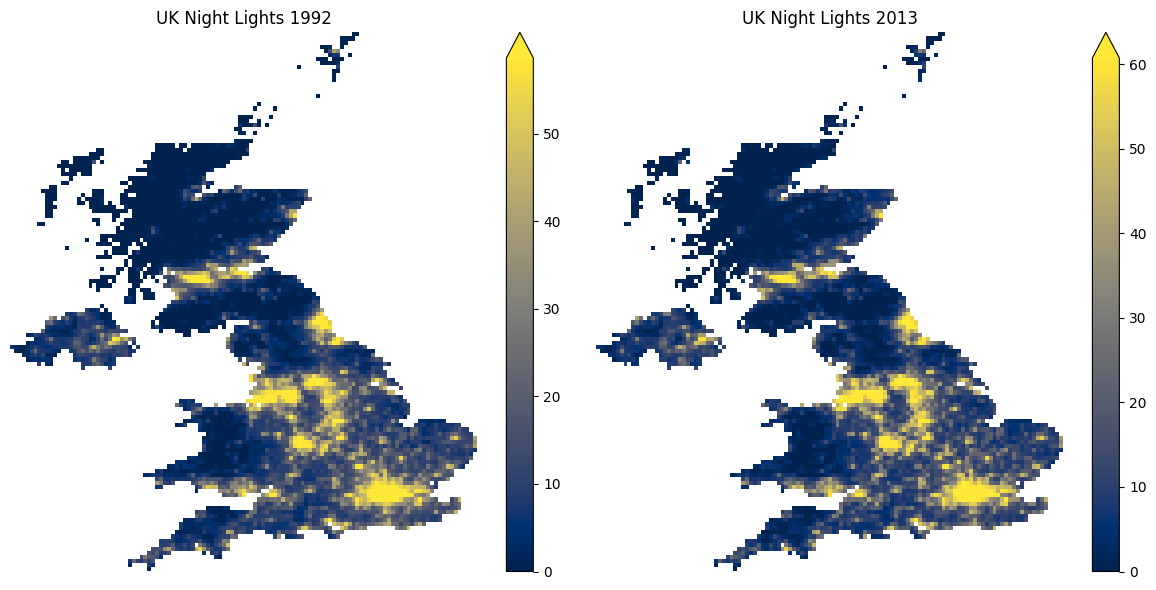

In [13]:
uk_counties = uk_counties.to_crs(nights_light_1992.rio.crs)
nights_light_1992_clip = nights_light_1992_small.rio.clip(uk_counties.geometry, drop=True)
nights_light_2013_clip = nights_light_2013_small.rio.clip(uk_counties.geometry, drop=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
nights_light_1992_clip.plot(ax=ax1, cmap='cividis', robust=True)
ax1.set_title("UK Night Lights 1992")
ax1.axis('off')
nights_light_2013_clip.plot(ax=ax2, cmap='cividis', robust=True)
ax2.set_title("UK Night Lights 2013")
ax2.axis('off')
plt.tight_layout()
plt.show()


### 5. Обчисліть середню світність для кожної області рівня 2.

In [14]:
stats_1992 = zonal_stats(uk_counties, nights_light_1992_path, stats=['sum', 'mean'], nodata=-9999, geojson_out=True)
stats_2013 = zonal_stats(uk_counties, nights_light_2013_path, stats=['sum', 'mean'], nodata=-9999, geojson_out=True)

In [15]:
stats_1992_gdf = gpd.GeoDataFrame.from_features(stats_1992)
stats_2013_gdf = gpd.GeoDataFrame.from_features(stats_2013)

stats_1992_gdf['year'] = 1992
stats_2013_gdf['year'] = 2013

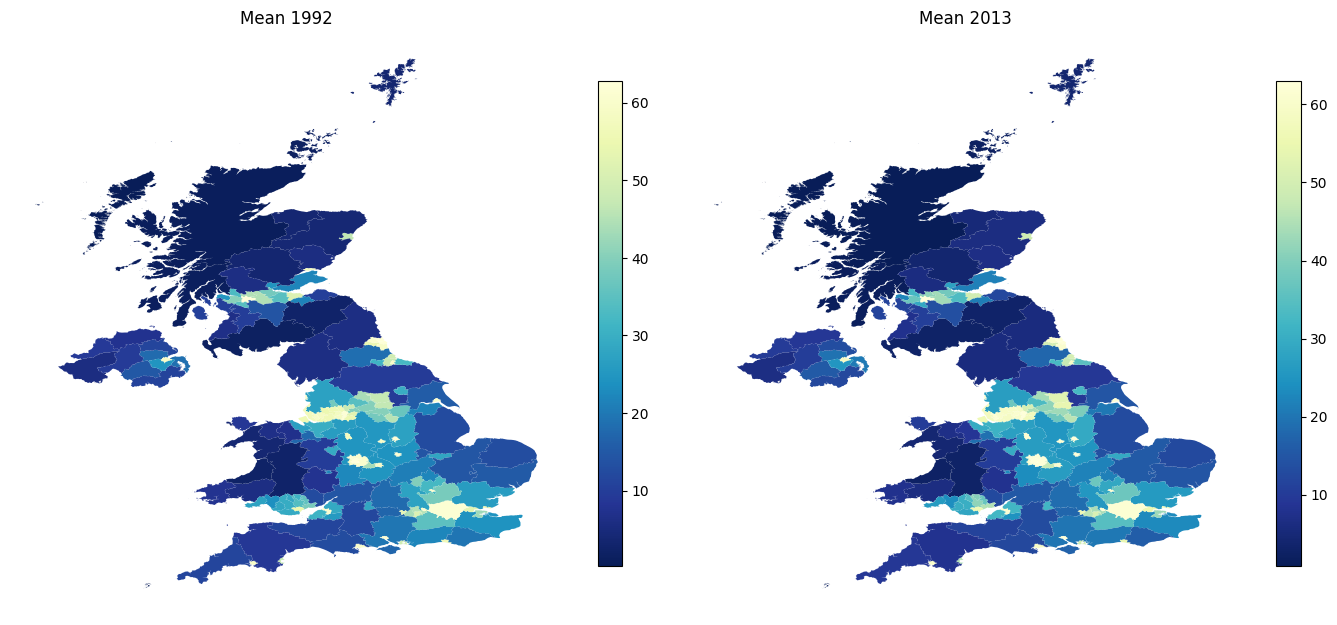

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
stats_1992_gdf.plot(column='mean', cmap='YlGnBu_r', legend=True,legend_kwds={'shrink': 0.5}, ax=ax1)
ax1.set_title("Mean 1992")
ax1.axis('off')
stats_2013_gdf.plot(column='mean', cmap='YlGnBu_r', legend=True, legend_kwds={'shrink': 0.5}, ax=ax2)
ax2.set_title("Mean 2013")
ax2.axis('off')

plt.tight_layout()

plt.show()

C:\Users\Andriy\AppData\Local\Temp\ipykernel_9988\2158132370.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


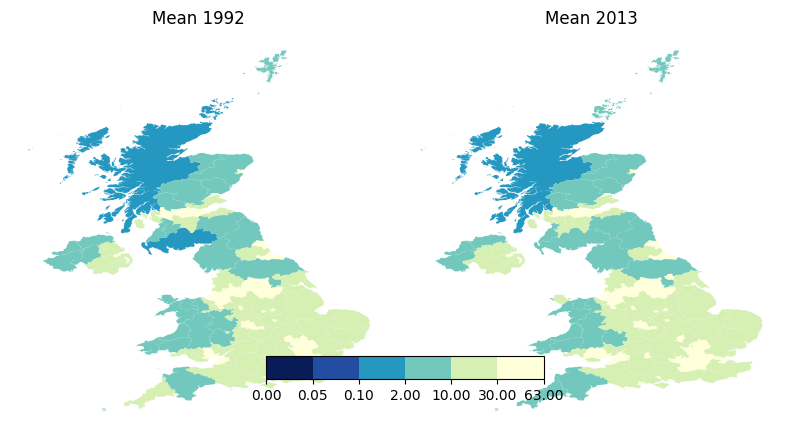

In [17]:
breaks = [0, 0.05, 0.1, 2, 10, 30, 63]
labels = ['0-0.05', '0.05-0.1', '0.1-2', '2-10', '10-30', '30-63']

# Create a custom colormap and normalization
cmap = plt.get_cmap('YlGnBu_r')
norm = mcolors.BoundaryNorm(breaks, cmap.N)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

# Plot for 1992 with custom colormap and breaks
stats_1992_gdf.plot(column='mean', cmap=cmap, norm=norm, legend=False, ax=ax1)
ax1.set_title("Mean 1992")
ax1.axis('off')

# Plot for 2013 with custom colormap and breaks
stats_2013_gdf.plot(column='mean', cmap=cmap, norm=norm, legend=False, ax=ax2)
ax2.set_title("Mean 2013")
ax2.axis('off')

# Add a colorbar to the figure
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=[ax1, ax2], orientation='horizontal', fraction=0.05, pad=0.18, aspect=12)

# Set ticks and labels to match the breaks
#cbar.set_ticks(breaks)
#cbar.set_ticklabels(labels)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

In [18]:
client.close()

### 6. Створіть результуючий GeoDataFrame з додатковим стовпцем, що показує різницю середньої світності між start_monthта end_month, і збережіть його у файлі. А, і не забудьте відобразити це на графіку.

In [19]:
stats_1992_gdf.head()

,geometry,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,mean,sum,year
0,"POLYGON ((-2.41998 51.29636, -2.41985 51.29626...",GBR.1.2_1,GBR,United Kingdom,GBR.1_1,England,NA,Bath and North East Somerset,NA,NA,Unitary Authority,Unitary Authority,NA,GB.BN,25.549467,16786.0,1992
1,"POLYGON ((-0.5112 52.0966, -0.51163 52.09579, ...",GBR.1.3_1,GBR,United Kingdom,GBR.1_1,England,NA,Bedford,NA,NA,Administrative County,NA,NA,GB.CB,22.245902,18998.0,1992
2,"POLYGON ((-2.45543 53.77399, -2.45488 53.77373...",GBR.1.5_1,GBR,United Kingdom,GBR.1_1,England,NA,Blackburn with Darwen,NA,NA,Unitary Authority,Unitary Authority,NA,GB.BW,37.992537,10182.0,1992
3,"POLYGON ((-3.03989 53.77958, -3.04253 53.7791,...",GBR.1.6_1,GBR,United Kingdom,NA,England,NA,Blackpool,NA,NA,NA,NA,NA,NA,60.950000,3657.0,1992
4,"MULTIPOLYGON (((-1.90538 50.72491, -1.90504 50...",GBR.1.72_1,GBR,United Kingdom,GBR.1_1,England,NA,"Bournemouth, Christchurch and Po",NA,NA,Unitary Authority,Unitary Authority,NA,GB.PL,59.741935,7408.0,1992


In [20]:
stats_2013_gdf.head()

,geometry,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,mean,sum,year
0,"POLYGON ((-2.41998 51.29636, -2.41985 51.29626...",GBR.1.2_1,GBR,United Kingdom,GBR.1_1,England,NA,Bath and North East Somerset,NA,NA,Unitary Authority,Unitary Authority,NA,GB.BN,24.552511,16131.0,2013
1,"POLYGON ((-0.5112 52.0966, -0.51163 52.09579, ...",GBR.1.3_1,GBR,United Kingdom,GBR.1_1,England,NA,Bedford,NA,NA,Administrative County,NA,NA,GB.CB,21.729508,18557.0,2013
2,"POLYGON ((-2.45543 53.77399, -2.45488 53.77373...",GBR.1.5_1,GBR,United Kingdom,GBR.1_1,England,NA,Blackburn with Darwen,NA,NA,Unitary Authority,Unitary Authority,NA,GB.BW,37.451493,10037.0,2013
3,"POLYGON ((-3.03989 53.77958, -3.04253 53.7791,...",GBR.1.6_1,GBR,United Kingdom,NA,England,NA,Blackpool,NA,NA,NA,NA,NA,NA,62.533333,3752.0,2013
4,"MULTIPOLYGON (((-1.90538 50.72491, -1.90504 50...",GBR.1.72_1,GBR,United Kingdom,GBR.1_1,England,NA,"Bournemouth, Christchurch and Po",NA,NA,Unitary Authority,Unitary Authority,NA,GB.PL,58.903226,7304.0,2013


In [21]:
merged_gdf = stats_1992_gdf[['NAME_1', 'geometry', 'mean']].merge(
    stats_2013_gdf[['NAME_1', 'mean']],
    on='NAME_1',
    suffixes=('_1992', '_2013')
)

In [22]:
merged_gdf['mean_diff'] = merged_gdf['mean_2013'] - merged_gdf['mean_1992']


In [23]:
merged_gdf.crs = "EPSG:4326"  

In [24]:
plot_gdf = merged_gdf.copy()
plot_gdf['geometry'] = plot_gdf['geometry'].simplify(tolerance=0.05, preserve_topology=True)

In [31]:
plot_gdf.to_file("UK_nightlights_diff.gpkg", layer="nightlights_diff", driver="GPKG")


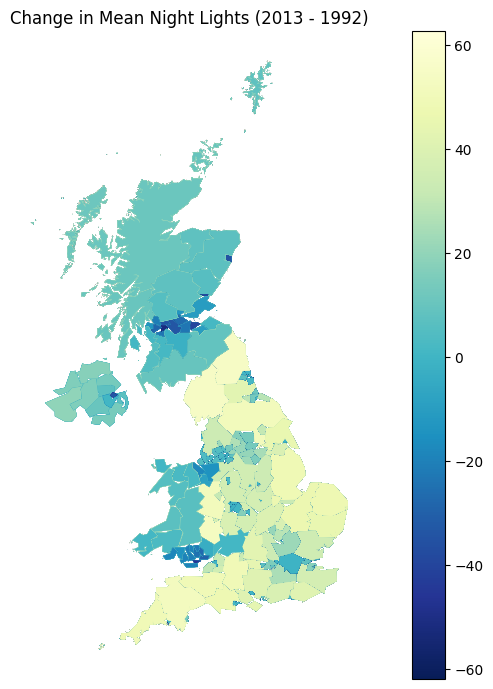

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
plot_gdf.plot(
    column='mean_diff',
    cmap='YlGnBu_r',      
    legend=True,
    legend_kwds={'shrink': 1},
    ax=ax
)
ax.set_title("Change in Mean Night Lights (2013 - 1992)")
ax.axis('off')
plt.tight_layout()
plt.show()